In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver.bpm_solver_cn import gauss, waveguide, beamprop_cn
import matplotlib.colors as color

# Beam Propagation Method (BPM) — Crank-Nicolson Solver

## Overview

This notebook implements a **1D finite-difference BPM** for simulating optical field propagation through a step-index planar waveguide. The paraxial wave equation is solved numerically using the **Crank-Nicolson (CN) implicit-explicit scheme**.

The simulation pipeline covers three stages:
1. **Waveguide definition** — step-index refractive index profile
2. **Input field initialization** — normalized Gaussian beam
3. **Field propagation** — CN solver marching along the z-axis

In [2]:
xa = 50        # Total transverse computation window width (μm)
xb = 2         # Waveguide core half-width (μm)
Nx = 251       # Number of transverse grid points
n_cladding = 1.45   # Refractive index of cladding
n_core = 1.46       # Refractive index of core
w = 5          # 1/e half-width of input Gaussian beam (μm)
z_end = 100    # Total propagation length (μm)
dz = 0.5       # Longitudinal step size (μm)
nd = 1.455     # BPM reference index
wl = 1         # Free-space wavelength (μm)
dx = xa / (Nx-1)    # Transverse grid spacing (μm), derived from xa and Nx

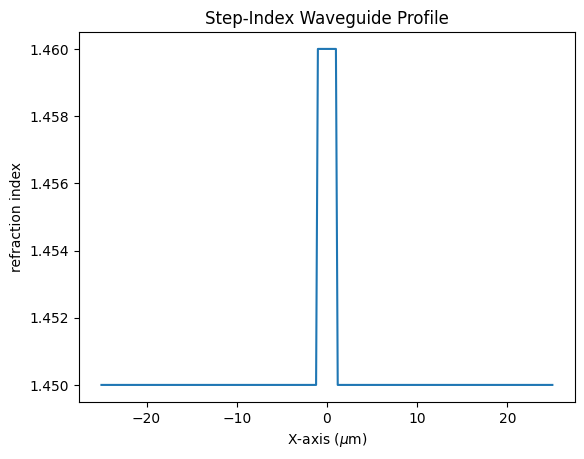

In [3]:
n, x = waveguide(xa, xb, Nx, n_cladding, n_core)
plt.plot(x, n)
plt.xlabel('X-axis ($\mu$m)')
plt.ylabel('refraction index')
plt.title('Step-Index Waveguide Profile')
plt.show()

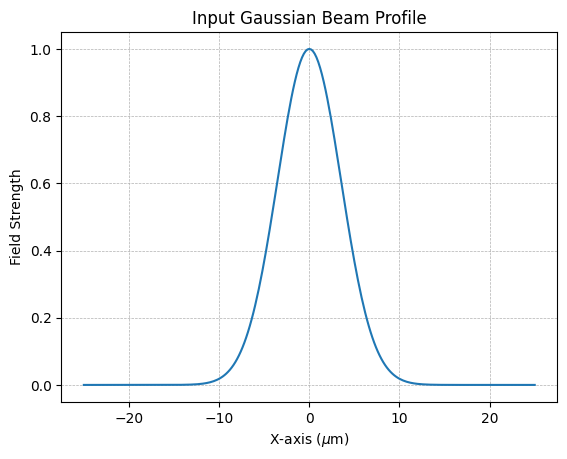

In [4]:
v_in, x = gauss(xa, Nx, w)
plt.plot(x, v_in)
plt.xlabel(r'X-axis ($\mu$m)')
plt.ylabel('Field Strength')
plt.grid(lw=0.5, linestyle='--')
plt.title('Input Gaussian Beam Profile')
plt.show()

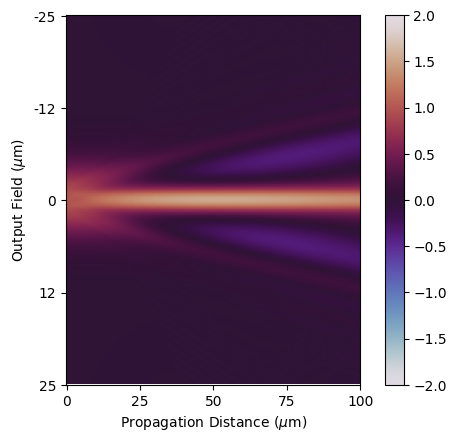

In [5]:
v_out, z = beamprop_cn(v_in, wl, dx, n, nd, z_end, dz)

norm = color.Normalize(-2., 2.)
im = plt.imshow(v_out.real, cmap="twilight", vmin=-2., vmax=2.)
plt.xlabel(r"Propagation Distance ($\mu$m)")
plt.ylabel("Output Field ($\mu$m)")
plt.yticks(np.linspace(0,Nx,5), np.linspace(-25, 25, 5).astype("int"))
plt.xticks(np.linspace(0,len(z),5), np.linspace(0, 100, 5).astype("int"))
plt.colorbar(im)
plt.show()